<p style="font-family:Nazanin; font-size:140%; text-align:center;" dir="rtl">
   «تحلیل داده‌ آگهی‌های دیوار»
</p>

In [ ]:
#!py -3.12 -m pip install geopy
#!py -3.12 -m pip install requests
#!py -3.12 -m pip install time

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
بارگذاری کتابخانه های مورد نیاز
</p>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import warnings
import re
warnings.filterwarnings("ignore")

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
بارگذاری داده های مورد نیاز
</p>

In [2]:
#data = pd.read_csv('/content/divar_real_estate_ads.csv', encoding="utf-8")
data = pd.read_csv('/content/sampled_data.csv',encoding = 'utf-8', engine='python')

<p style="font-family:Nazanin; font-size:130%; text-align:right;color:blue;" dir="rtl">
    بخش اول : بررسی کیفیت داده
</p>
<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    1. مقادیر ناموجود در هر یک از ستون‌ها را بررسی و ستون‌ها و ردیف‌هایی که مقادیر موجود بیشتری دارند را مشخص کنید .
</p>

In [ ]:
df_na = data.isna().sum().reset_index()
df_na.columns = ["column", "missing_nums"]
df_na["percent_missing"] = (df_na["missing_nums"] / len(data)) * 100
# sort columns from lowest number of NA's to the highest
df_na = df_na.sort_values(by="percent_missing", ascending=True)
print("columns with lowest number of NA's")
print(df_na.head(5))
print("\n")
print("columns with highest number of NA's")
print((df_na.tail(20)))
data['deed_type'].value_counts()

columns with lowest number of NA's
             column  missing_nums  percent_missing
0         cat2_slug             0              0.0
1         cat3_slug             0              0.0
2         city_slug             0              0.0
4  created_at_month             0              0.0
6       description             0              0.0


columns with highest number of NA's
                        column  missing_nums  percent_missing
11                   rent_type        134506        89.670667
21            transformed_rent        139186        92.790667
19          transformed_credit        139186        92.790667
25           has_business_deed        144786        96.524000
39                     has_gas        145008        96.672000
36                   has_water        145009        96.672667
38             has_electricity        145011        96.674000
43          has_security_guard        145355        96.903333
44                has_barbecue        145380        96.920000
5

,count
deed_type,
single_page,29269
written_agreement,4785
other,3098
multi_page,1014
unselect,85


<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    2. آیا ردیف‌های تکراری در داده وجود دارد؟
</p>

In [ ]:
print('number of duplicated rows: ',data.duplicated(keep = 'last').sum())


number of duplicated rows:  0


<p style="font-family:Nazanin; font-size:130%; text-align:right;color:blue;" dir="rtl">
    بخش دوم : تحلیل اکتشافی داده (EDA)
</p>

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    1. توزیع و مشخصه‌های آماری هر یک از ستون‌ها (متغیرهای عددی) را ترسیم و بررسی کنید.
</p>

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    2. ارتباط دو به دوی تعدادی از متغیرها را که تصور می‌کنید به فهم داده کمک می‌کنند، بررسی کنید.
</p>

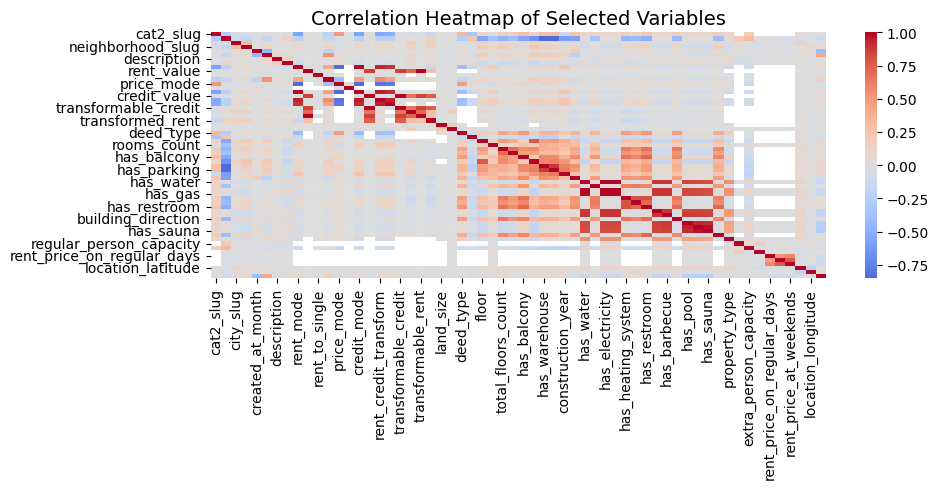

Pairs of columns with absolute correlation > 0.8:
there is strong negative correlation between price_mode - rent_mode: -0.840 

there is strong positive correlation between credit_mode - rent_mode: 0.985 

there is strong negative correlation between credit_mode - price_mode: -0.852 

there is strong positive correlation between credit_value - rent_value: 0.849 

there is strong positive correlation between rent_credit_transform - rent_mode: 0.939 

there is strong negative correlation between rent_credit_transform - price_mode: -0.816 

there is strong positive correlation between rent_credit_transform - credit_mode: 0.955 

there is strong positive correlation between transformable_price - rent_mode: 0.905 

there is strong positive correlation between transformable_price - credit_mode: 0.923 

there is strong positive correlation between transformable_price - rent_credit_transform: 0.945 

there is strong positive correlation between transformable_credit - rent_value: 0.849 

there 

In [ ]:

data_clean = data.copy()

# Convert booleans-like strings to numeric 1/0
bool_cols = [c for c in data_clean.columns if data_clean[c].dtype == 'object' and
             set(data_clean[c].dropna().unique()).issubset({'TRUE', 'FALSE', 'True', 'False','true','false'})]

for col in bool_cols:
    data_clean[col] = data_clean[col].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0})

# Convert categorical columns to category codes
for col in data_clean.columns:
    if data_clean[col].dtype == 'object':
        data_clean[col] = data_clean[col].astype('category').cat.codes


#save this dataframe for later process
#data_clean.to_csv('divar_clean.csv',index = False)

corr_matrix = data_clean.corr(numeric_only=True)

# Visualize correlations (heatmap)
plt.figure(figsize=(10,5))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Selected Variables', fontsize=14)
plt.tight_layout()
plt.savefig("heatmap.png", dpi=300)
plt.show()

#findout the correlation between values in corr_matrix
high_corr_pairs = []
# Iterate through the correlation matrix
for i in range(len(corr_matrix.columns)):
    for j in range(i): # Start from j=0 to avoid duplicate pairs and the diagonal
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            correlation_value = corr_matrix.iloc[i, j]
            high_corr_pairs.append((col1, col2, correlation_value))

# Print the pairs
print("Pairs of columns with absolute correlation > 0.8:")
for pair in high_corr_pairs:
    if pair[2] > 0 :
      print(f"there is strong positive correlation between {pair[0]} - {pair[1]}: {pair[2]:.3f} \n")
    else:
      print(f"there is strong negative correlation between {pair[0]} - {pair[1]}: {pair[2]:.3f} \n")


<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    3. نکات قابل توجهی را که از بررسی توزیع‌ها و نمودارهای پراکندگی و مقدار همبستگی دریافتید فهرست کنید.
</p>

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    3. آیا چیزی از جنس تناقض و ناسازگاری مقداری در داده مشاهده می‌کنید؟ به عنوان نمونه به این صورت که در یک سلول مقدار غیرمرتبط و از نظر منطقی نادرست نوشته شده باشد. مثلا در ستونی که قرار است متن بیاید عدد آمده باشد یا در ستونی که قرار است عدد یک یا دو رقمی بیاید، مقدار متفاوتی ثبت شده است.
</p>

# from here  ....

In [3]:
#calculate price per square meter and rent per square meter
data2 = data.copy()
data2['price_per_meter'] = (data2['price_value'] / data2['building_size'])/1000000

#since we have credit and rent price we need total rent
data2['total_rent'] = data2['rent_value']*30 + data2['credit_value']
data2['rent_price_per_meter'] = (data2['total_rent'] / data2['building_size'])/1000000


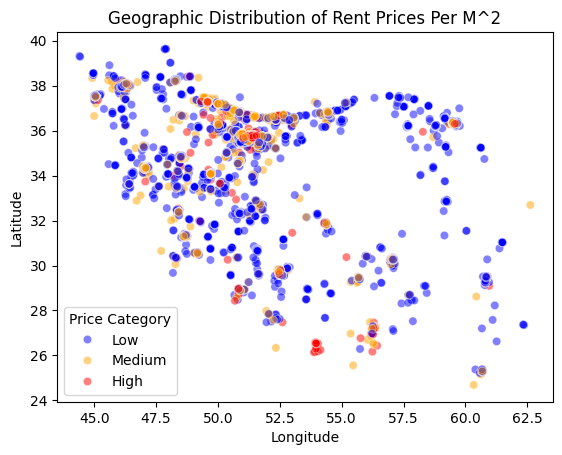

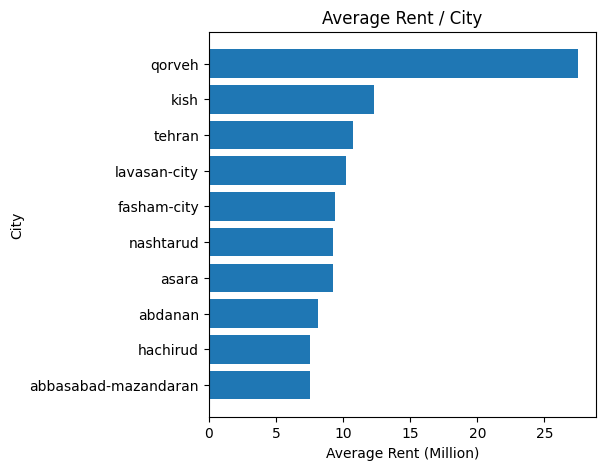

In [ ]:
# Calculate Q1, Q3, and IQR for 'price_value'
Q1 = data2['total_rent'].quantile(0.25)
Q3 = data2['total_rent'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers and filter the data based on the index of non-outliers

data4 = data2[(data2['cat2_slug']=='residential-rent') &
              (data2['cat3_slug']=='apartment-rent') &
              (data2['total_rent'] > lower_bound) &
              (data2['total_rent'] < upper_bound)]

bins = [data4['rent_price_per_meter'].min()-1, data4['rent_price_per_meter'].quantile(0.33),
       data4['rent_price_per_meter'].quantile(0.66), data4['rent_price_per_meter'].max()+1]
labels = ['Low', 'Medium', 'High']

data4['price_category'] = pd.cut(data4['rent_price_per_meter'], bins=bins, labels=labels)


sns.scatterplot(
    x='location_longitude',
    y='location_latitude',
    hue='price_category',
    data=data4,
    palette={'Low':'blue', 'Medium':'orange', 'High':'red'},
    alpha=0.5
)
plt.title('Geographic Distribution of Rent Prices Per M^2')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Price Category')
plt.show()

avg_rent_per_city = data4.groupby('city_slug')['rent_price_per_meter'].mean().reset_index()
avg_rent_per_city = avg_rent_per_city.sort_values('rent_price_per_meter', ascending=False)
avg_rent_per_city[avg_rent_per_city['rent_price_per_meter'].notnull()]
avg_rent_per_city = avg_rent_per_city.head(10)
plt.figure(figsize = (5, 5))

plt.barh(
    avg_rent_per_city['city_slug'],
    avg_rent_per_city['rent_price_per_meter']
)
plt.xlabel('Average Rent (Million)')
plt.ylabel('City')
plt.title('Average Rent / City')
plt.gca().invert_yaxis()
plt.show()



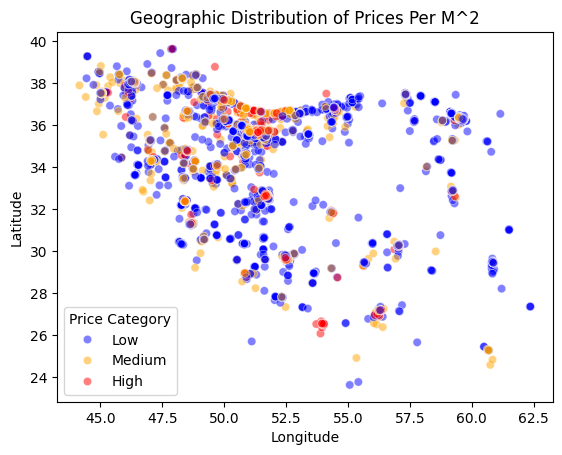

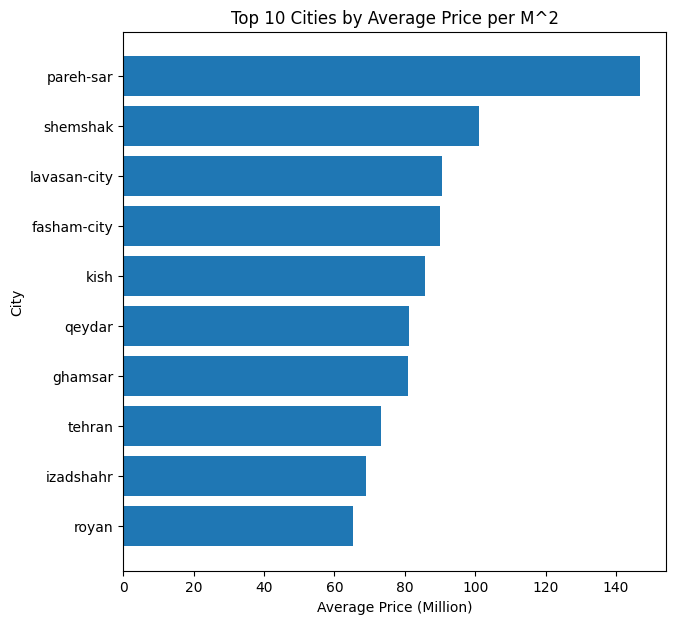

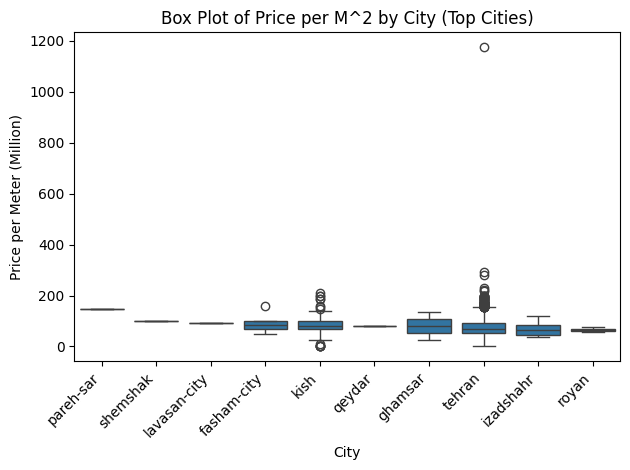

In [ ]:
# Calculate Q1, Q3, and IQR for 'price_value'
Q1 = data2['price_value'].quantile(0.25)
Q3 = data2['price_value'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers and filter the data based on the index of non-outliers

data3 = data2[(data2['cat2_slug']=='residential-sell') &
              (data2['cat3_slug']=='apartment-sell') &
              (data2['price_value'] > lower_bound) &
              (data2['price_value'] < upper_bound)]

bins = [data3['price_per_meter'].min()-1, data3['price_per_meter'].quantile(0.33),
       data3['price_per_meter'].quantile(0.66), data3['price_per_meter'].max()+1]
labels = ['Low', 'Medium', 'High']

data3['price_category'] = pd.cut(data3['price_per_meter'], bins=bins, labels=labels)


sns.scatterplot(
    x='location_longitude',
    y='location_latitude',
    hue='price_category',
    data=data3,
    palette={'Low':'blue', 'Medium':'orange', 'High':'red'},
    alpha=0.5
)
plt.title('Geographic Distribution of Prices Per M^2')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Price Category')
plt.show()



avg_price_per_city = data3.groupby('city_slug')['price_per_meter'].mean().reset_index()
avg_price_per_city = avg_price_per_city.sort_values('price_per_meter', ascending=False)

avg_price_per_city = avg_price_per_city[avg_price_per_city['price_per_meter'].notnull()]

# Select top 10 cities for the bar chart
avg_price_per_city_top10 = avg_price_per_city.head(10)


plt.figure(figsize = (7, 7))
plt.barh(
    avg_price_per_city_top10['city_slug'],
    avg_price_per_city_top10['price_per_meter']
)
plt.xlabel('Average Price (Million)')
plt.ylabel('City')
plt.title('Top 10 Cities by Average Price per M^2')
plt.gca().invert_yaxis()
plt.show()

top_cities = avg_price_per_city.head(10)['city_slug'].tolist()
data3_top_cities = data3[data3['city_slug'].isin(top_cities)].copy()

#plt.figure(figsize=(7, 7))
sns.boxplot(x='city_slug', y='price_per_meter', data=data3_top_cities, order=top_cities) # Order by average price
plt.title('Box Plot of Price per M^2 by City (Top Cities)')
plt.xlabel('City')
plt.ylabel('Price per Meter (Million)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

دیتا فریم مربوط به آگهی هایی که رنج قیمت برای هر مترمربع چه اجاره و چه فروش معقول است.

In [ ]:

data2_copy = data2.copy()
# Calculate Q1, Q3, and IQR for 'price_value'
Q1_p = data2['price_per_meter'].quantile(0.25)
Q3_p = data2['price_per_meter'].quantile(0.75)
IQR_p = Q3_p - Q1_p

# Define the lower and upper bounds for outliers
lower_bound_p = Q1_p - 1.5 * IQR_p
upper_bound_p = Q3_p + 1.5 * IQR_p

Q1_r = data2['rent_price_per_meter'].quantile(0.25)
Q3_r = data2['rent_price_per_meter'].quantile(0.75)
IQR_r = Q3_r - Q1_r

# Define the lower and upper bounds for outliers
lower_bound_r = Q1_r - 1.5 * IQR_r
upper_bound_r = Q3_r + 1.5 * IQR_r

data2_copy = data2_copy[(data2_copy['price_per_meter'] > lower_bound_p) & (data2_copy['price_per_meter'] < upper_bound_p) |
                   (data2_copy['rent_price_per_meter'] > lower_bound_r) & (data2_copy['rent_price_per_meter'] < upper_bound_r)
                   ]


#remove price outliers
data2_copy.shape

(126025, 63)

قیمت هر مترمربع آگهی ها برای فروش بر اساس سال ساخت

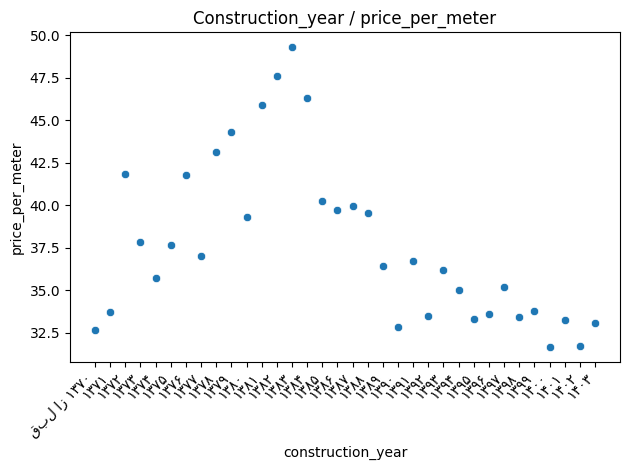

In [ ]:
avg_price_per_year = data2_copy.groupby('construction_year')['price_per_meter'].mean().reset_index()
avg_price_per_year = avg_price_per_year.sort_values('construction_year', ascending=True)
avg_price_per_year = avg_price_per_year[avg_price_per_year['price_per_meter'].notnull()]

#plt.figure(figsize = (15, 5))
sns.scatterplot(x = 'construction_year', y = 'price_per_meter', data = avg_price_per_year)
plt.title('Construction_year / price_per_meter')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

قیمت اجاره هر مترمربع بر اساس سال ساخت


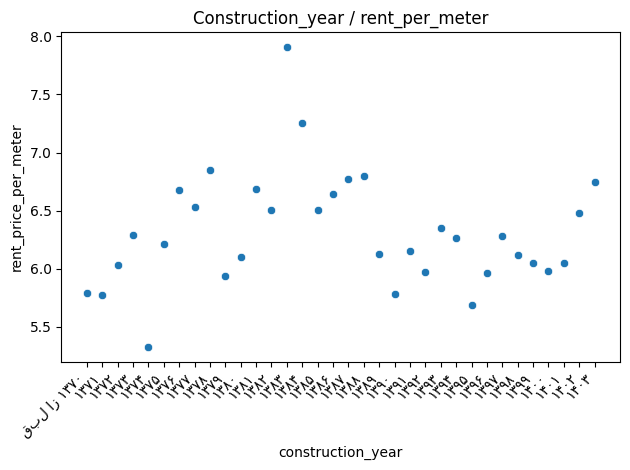

In [ ]:
avg_rent_per_year = data2_copy.groupby('construction_year')['rent_price_per_meter'].mean().reset_index()
avg_rent_per_year = avg_rent_per_year.sort_values('construction_year', ascending=True)
avg_rent_per_year = avg_rent_per_year[avg_rent_per_year['rent_price_per_meter'].notnull()]

#plt.figure(figsize = (10, 5))
sns.scatterplot(x = 'construction_year', y = 'rent_price_per_meter', data = avg_rent_per_year)
plt.title('Construction_year / rent_per_meter')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

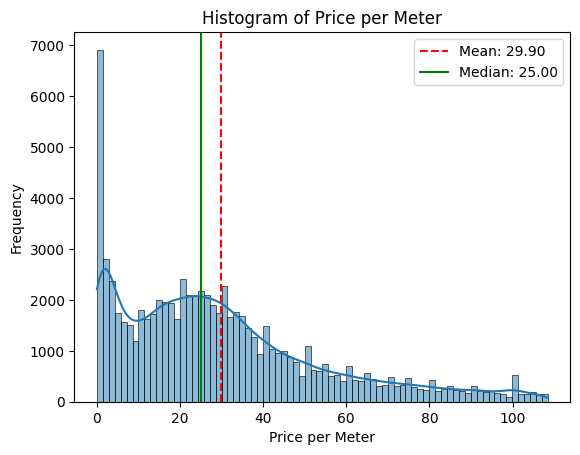

In [ ]:
from scipy.stats import skew
data2_copy = data2.copy()
# Calculate Q1, Q3, and IQR for 'price_value'
Q1_p = data2['price_per_meter'].quantile(0.25)
Q3_p = data2['price_per_meter'].quantile(0.75)
IQR_p = Q3_p - Q1_p

# Define the lower and upper bounds for outliers
lower_bound_p = Q1_p - 1.5 * IQR_p
upper_bound_p = Q3_p + 1.5 * IQR_p

data2_copy = data2_copy[(data2_copy['price_per_meter'] > lower_bound_p) & (data2_copy['price_per_meter'] < upper_bound_p)]
#pd.save

#data2_copy.shape
#print(skew(data2[data2['price_per_meter'].notnull()]['price_per_meter']))
#print(skew(data2[data2['rent_price_per_meter'].notnull()]['rent_price_per_meter']))
#print(skew(data2['rent_price_per_meter']))

price_per_meter = data2_copy[data2_copy['price_per_meter'].notnull()]['price_per_meter'].round(2)

mean = np.mean(price_per_meter)
median = np.median(price_per_meter)

sns.histplot(price_per_meter, kde=True)


plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.2f}')


plt.axvline(median, color='green', linestyle='-', label=f'Median: {median:.2f}')

plt.title('Histogram of Price per Meter')
plt.xlabel('Price per Meter')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
#داده های قبل و بعد از چارک اول و سوم که به عنوان پرت در نظر گرفته شده است  جدا شده اند
data_less_Q1 = data2[data2['price_per_meter']<Q1_p]
data_big_Q3 = data2[data2['price_per_meter']>Q3_p]
data_less_Q1.to_csv('less_Q1.csv', index=False)
data_big_Q3.to_csv('big_Q3.csv', index=False)

**ارزانترین شهرها برای اجاره مسکن**



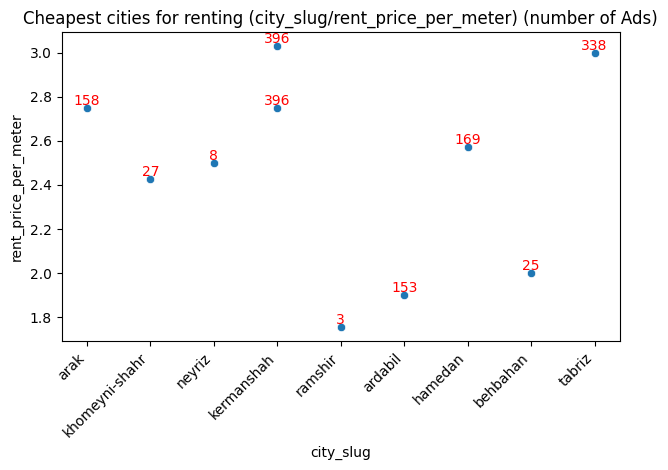

In [ ]:
#cheap city for renting

Q1_r = data2['rent_price_per_meter'].quantile(0.25)
Q3_r = data2['rent_price_per_meter'].quantile(0.75)
IQR_r = Q3_r - Q1_r

# Define the lower and upper bounds for outliers
lower_bound_r = Q1_r - 1.5 * IQR_r
upper_bound_r = Q3_r + 1.5 * IQR_r

#consider non-outliers data
df_rent = data2[(data2['rent_price_per_meter'] >= lower_bound_r) & (data2['rent_price_per_meter'] <= upper_bound_r)]

df_rent = df_rent[data2['cat2_slug'].str.find('rent') != -1]

city_cheap_rent = df_rent[df_rent['rent_price_per_meter'] < Q1_r][['city_slug','rent_price_per_meter']]

city_cheap_rent.groupby('city_slug')['rent_price_per_meter'].mean().sort_values(ascending=False)

city_counts = city_cheap_rent['city_slug'].value_counts().reset_index(name='count')

city_cheap_rent = city_cheap_rent.merge(city_counts, on='city_slug')

#print(city_cheap_rent.head(10))
#plt.figure(figsize = (10, 5))

sns.scatterplot(x = 'city_slug', y = 'rent_price_per_meter', data = city_cheap_rent.head(10))
plt.title('Cheapest cities for renting (city_slug/rent_price_per_meter) (number of Ads)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
for i,row in city_cheap_rent.head(10).iterrows():
    plt.text(row['city_slug'], row['rent_price_per_meter'], str(row['count']), ha='center', va='bottom',color = 'red')

plt.show()

<div dir="rtl">
  <h2> شناسایی محله‌های سودآور سرمایه‌گذاری، باید دو شاخص کلیدی را به‌صورت همزمان تحلیل کنیم:</h2>
  <p> هدف:</p>
  <p>پیدا کردن محله‌هایی که:</p>
  <ul>
    <li>رشد قیمت پایدار یا مثبت در طول زمان دارند (قیمت رو به افزایش و نه نوسانی یا نزولی)،</li>
    <li>عرضهٔ کم (تعداد آگهی کم نسبت به سایر محله‌ها) &rArr; یعنی تقاضا بالاتر از عرضه است، پس ملک دیرتر خالی می‌ماند و ارزش سرمایه‌ای بیشتر می‌شود.</li>
  </ul>
</div>


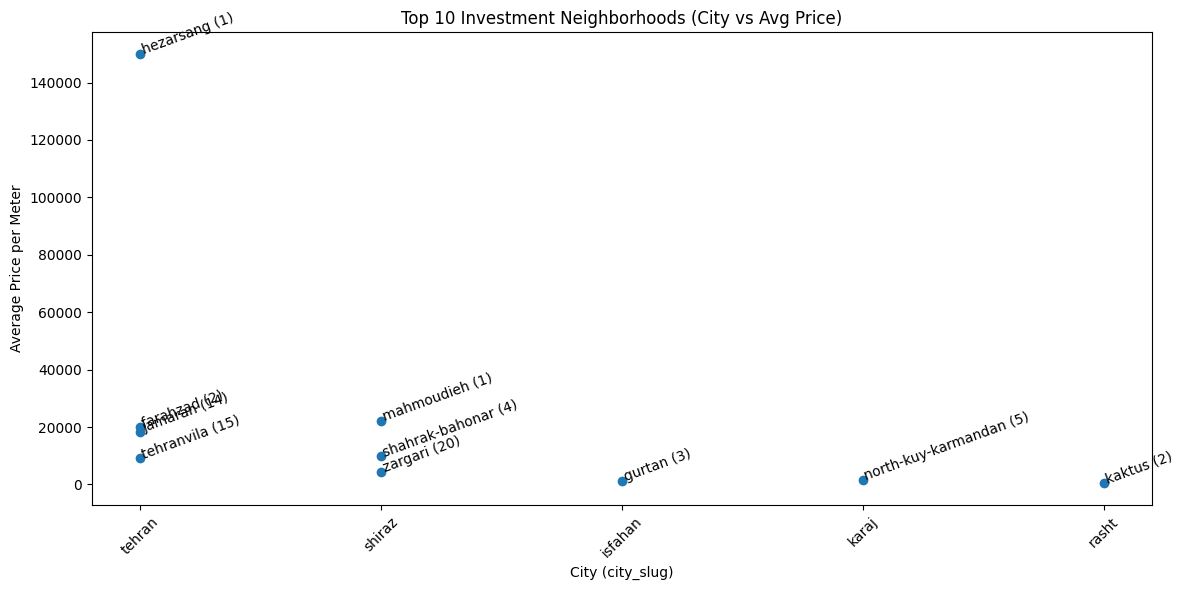

In [ ]:
columns_need= ['city_slug', 'neighborhood_slug', 'price_per_meter']
df = data2[columns_need].copy()

df = df.dropna(subset=['city_slug', 'neighborhood_slug', 'price_per_meter'])

# Group by city and neighborhood to get average price and number of ads
grouped = df.groupby(['city_slug', 'neighborhood_slug']).agg(
    avg_price_per_meter = ('price_per_meter', 'mean'),
    median_price_per_meter = ('price_per_meter', 'median'),
    ad_count = ('price_per_meter', 'count')
).reset_index()

#Sort results by average price
grouped_sorted = grouped.sort_values(by='avg_price_per_meter', ascending=False)


grouped['investment_score'] = (
    (grouped['avg_price_per_meter'] / grouped['avg_price_per_meter'].max()) *
    (1 / (grouped['ad_count']))
)


top_10 = grouped.sort_values(by='investment_score', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.scatter(top_10['city_slug'], top_10['avg_price_per_meter'])

for i in range(len(top_10)):
    plt.text(
        (top_10['city_slug'].iloc[i]),
        top_10['avg_price_per_meter'].iloc[i],
        f"{top_10['neighborhood_slug'].iloc[i]} ({top_10['ad_count'].iloc[i]})",
        fontsize=10,
        rotation=20    )

plt.xlabel("City (city_slug)")
plt.ylabel("Average Price per Meter")
plt.title("Top 10 Investment Neighborhoods (City vs Avg Price)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df = data2[['construction_year','price_per_meter']].copy()

In [ ]:
print(df['construction_year'].dtype)
print(df['construction_year'].unique())


object
['۱۳۹۰' '۱۴۰۳' '۱۴۰۲' '۱۳۹۹' nan '۱۳۹۷' '۱۳۹۵' '۱۳۸۵' '۱۳۷۲' '۱۳۸۶' '۱۳۸۹'
 '۱۴۰۱' '۱۳۹۳' '۱۳۹۴' '۱۳۸۸' '۱۳۹۸' '۱۳۹۶' '۱۳۷۶' '۱۳۷۱' '۱۳۸۷' '۱۳۷۴'
 '۱۳۹۲' '۱۴۰۰' 'قبل از ۱۳۷۰' '۱۳۸۱' '۱۳۹۱' '۱۳۸۰' '۱۳۷۹' '۱۳۸۲' '۱۳۸۳'
 '۱۳۷۳' '۱۳۷۸' '۱۳۷۵' '۱۳۸۴' '۱۳۷۷']


In [ ]:
persian_to_english_digits = str.maketrans('۰۱۲۳۴۵۶۷۸۹', '0123456789')

def convert_persian_year_to_english(year_str):
    if pd.isna(year_str):
        return np.nan
    year_str = str(year_str).strip()
    if 'قبل از' in year_str:
        return 1369
    try:
        # Convert Persian digits to English digits
        english_year_str = year_str.translate(persian_to_english_digits)
        return int(english_year_str)
    except ValueError:
        return np.nan

# Apply the conversion function
df['construction_year'] = df['construction_year'].apply(convert_persian_year_to_english)

# Convert the column to numeric, coercing errors to NaN
df['construction_year'] = pd.to_numeric(df['construction_year'], errors='coerce')

# Remove rows where construction_year is NaN
original_rows = df.shape[0]
df.dropna(subset=['construction_year'], inplace=True)
removed_rows = original_rows - df.shape[0]

max_year = df['construction_year'].max()
recent_years = [year for year in range(int(max_year) - 4, int(max_year) + 1)]

print(f"Considering recent construction years from {min(recent_years)} to {max_year}.")

Q3_price_per_meter = df['price_per_meter'].quantile(0.75)

print(f"The 75th percentile (Q3) for 'price_per_meter' is: {Q3_price_per_meter}")

recent_construction_data = df[df['construction_year'].isin(recent_years)]

high_priced_new_houses = recent_construction_data[recent_construction_data['price_per_meter'] > Q3_price_per_meter]

percentage_high_priced_new_houses = (len(high_priced_new_houses) / len(recent_construction_data)) * 100 if len(recent_construction_data) > 0 else 0

print(f"Number of houses built in recent years ({min(recent_years)}-{max(recent_years)}): {len(recent_construction_data)}")
print(f"Number of high-priced houses among these: {len(high_priced_new_houses)}")
print(f"Percentage of high-priced new houses: {percentage_high_priced_new_houses:.2f}%")

Considering recent construction years from 1399 to 1403.0.
The 75th percentile (Q3) for 'price_per_meter' is: 58.06451612903226
Number of houses built in recent years (1399-1403): 43884
Number of high-priced houses among these: 6014
Percentage of high-priced new houses: 13.70%


**Reasoning**:
To visualize the percentage of high-priced new houses, we created a pie chart using the calculated percentage and its complement




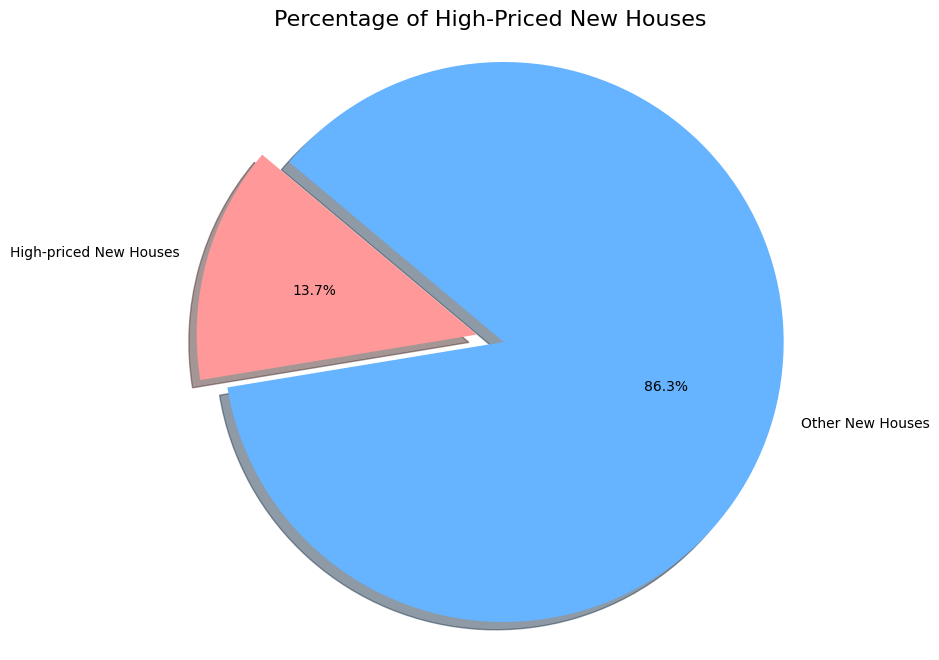

In [ ]:
labels = ['High-priced New Houses', 'Other New Houses']
sizes = [percentage_high_priced_new_houses, 100 - percentage_high_priced_new_houses]
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0)  # Explode the 1st slice (High-priced New Houses)

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Percentage of High-Priced New Houses', fontsize=16)
plt.show()

substitute building size with 1 m^2 with the meter extracted from description

In [ ]:

df = data2[['description','building_size']]
df['description'] = df['description'].astype(str)

def extract_meter_numbers(description):
    if pd.isna(description):
        return np.nan
    matches = re.findall(r'(\d+)\s*متر\s*', description)
    if matches:
        return float(matches[0])
    return np.nan

df['meter_numbers'] = df['description'].apply(extract_meter_numbers)
df.to_csv('meter.csv', index=False,encoding = 'utf-8')
counter = 0
for row in df.itertuples():
  if row.building_size == 1:
    df['building_size'][counter] = row.meter_numbers
  counter += 1

df.head()

,description,building_size,meter_numbers
0,✔مناسب مشاغل پروتئنی و دفتر بیمه و لبنیات \n...,25.0,NaN
1,با سلام خدمت هشهریان عزیز\n\nواحد دومین قطعه ا...,102.0,102.0
2,۱۳۵ متر واحد لوکس به همراه تراس قابل چیدمان \n...,168.0,135.0
3,⚜️⚜️⚜️املاک بزرگ باور⚜️⚜️⚜️\n\n56 متر غرق در ن...,56.0,56.0
4,سلام درود همشهریان و مهمان های عزیز با ما با ب...,200000.0,NaN


In [ ]:
data.columns

Index(['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 'rent_mode',
       'rent_value', 'rent_to_single', 'rent_type', 'price_mode',
       'price_value', 'credit_mode', 'credit_value', 'rent_credit_transform',
       'transformable_price', 'transformable_credit', 'transformed_credit',
       'transformable_rent', 'transformed_rent', 'land_size', 'building_size',
       'deed_type', 'has_business_deed', 'floor', 'rooms_count',
       'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt',
       'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type',
       'regular_person_capacity', 'extra_person

ذینفع : طراحان داخلی

با استفاده از این روش تحلیلی، می‌توانیم شهرها و مناطقی را شناسایی کنیم که بالاترین پتانسیل برای ارائه خدمات طراحی داخلی را دارند. این تحلیل بر اساس داده‌های واقعی املاک انجام می‌شود و به شما کمک می‌کند تا تصمیم‌گیری دقیق‌تر و هدفمندتری داشته باشید.

به کمک این روش می‌توانید:

✅ تشخیص دهید کدام شهرها بیشترین ظرفیت و تقاضا برای پروژه‌های طراحی داخلی را دارند.

✅ بفهمید در کدام مناطق تعداد بازسازی و نوسازی بیشتر است؛ یعنی مشتریانی که آماده همکاری با طراح داخلی هستند.

✅ شناسایی کنید کدام مناطق دارای بیشترین فایل پیش‌فروش هستند؛ یعنی ساختمان‌های تازه‌ساز با پتانسیل طراحی داخلی از صفر.

✅ بررسی کنید در کدام مناطق میانگین متراژ واحدها بالاتر است؛ یعنی پروژه‌هایی بزرگ‌تر، لوکس‌تر و سودآورتر برای طراح داخلی.

Top 10 Cities for Interior Design Opportunities:
          city_slug  rebuilt_count  pre_sell_count  avg_building_size  \
88           chobar            1.0             0.0      400809.000000   
264        molkabad            1.0             0.0      297139.315789   
315          reyneh            0.0             0.0      252628.250000   
178        kangavar           12.0             0.0      144210.402778   
132  galougah-babol            0.0             0.0      112701.812500   
99         dehgolan            5.0             1.0      112235.297872   
19        aligudarz           12.0             0.0      104514.666667   
255        miandoab            8.0             0.0      101361.125000   
251          mehran            3.0             0.0       99462.909091   
168        javanrud            3.0             1.0       81494.758065   

            score  
88   40081.500000  
264  29714.531579  
315  25262.825000  
178  14428.240278  
132  11270.181250  
99   11226.829787  
19   10

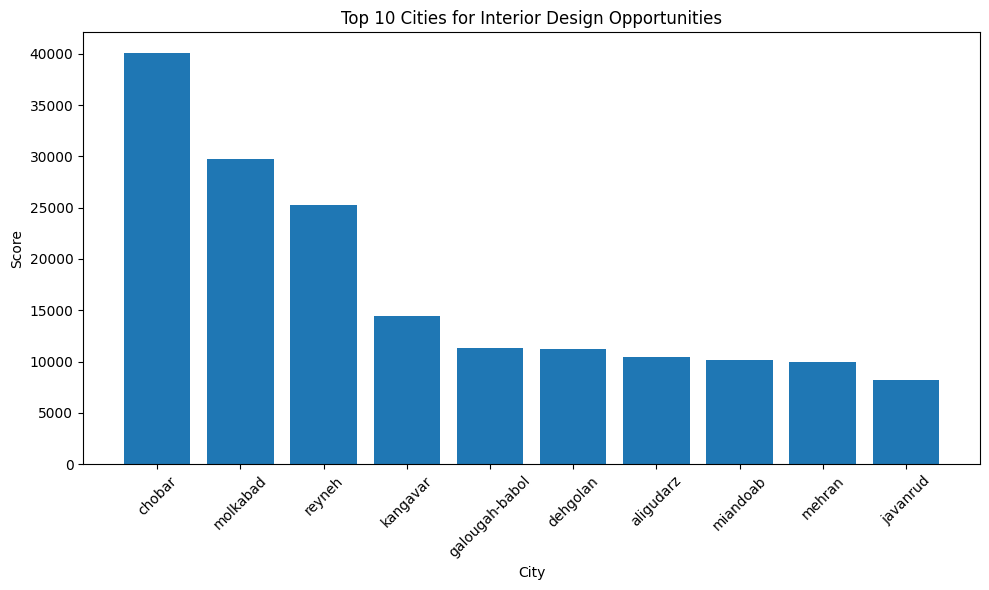

In [ ]:
df = data2[['cat3_slug','city_slug', 'neighborhood_slug', 'price_per_meter','building_size','is_rebuilt']].copy()
rebuilt_houses = df[df['is_rebuilt'] == True]
pre_sell = df[df['cat3_slug'] == 'presell']

rebuilt_by_city = rebuilt_houses.groupby('city_slug').size().reset_index(name='rebuilt_count')
pre_sell_by_city = pre_sell.groupby('city_slug').size().reset_index(name='pre_sell_count')
large_houses = df.groupby('city_slug')['building_size'].mean().reset_index(name='avg_building_size')

#merge all these
city_summary = rebuilt_by_city.merge(pre_sell_by_city, on='city_slug', how='outer') \
                              .merge(large_houses, on='city_slug', how='outer')

#calculat a score based on the importannce of each feature! rebuilt is most important.
city_summary = city_summary.fillna(0)
city_summary['score'] = (
    city_summary['rebuilt_count'] * 0.6 +
    city_summary['pre_sell_count'] * 0.3 +
    city_summary['avg_building_size'] * 0.1
)

best_cities = city_summary.sort_values('score', ascending=False).head(10)

#plot
plt.figure(figsize=(10, 6))
plt.bar(best_cities['city_slug'], best_cities['score'])
plt.title('Top 10 Cities for Interior Design Opportunities')
plt.xlabel('City')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<p>با استفاده از این تحلیل:</p>
<ul>
  <li>✔ مشخص می‌کنید <strong>کدام شهرها و محله‌ها بیشترین سود را برای راه‌اندازی دفتر دارند</strong>.</li>
  <li>✔ مناطقی که ترکیبی از قیمت بالا، واحدهای بزرگ و معاملات متعدد دارند، به عنوان <strong>مناطق بهینه برای تمرکز فعالیت</strong> شناسایی می‌شوند.</li>
  <li>✔ تصمیم‌گیری شما برای جذب مشتری و انتخاب محل دفتر با داده‌های واقعی و عددی پشتیبانی می‌شود.</li>
</ul>

<p>بنابراین، تحلیل Profit Score به شما امکان می‌دهد <strong>استراتژی هوشمندانه‌ای برای افزایش سود و بهره‌وری کسب‌وکار مشاور املاک</strong> طراحی کنید.</p>
</div>


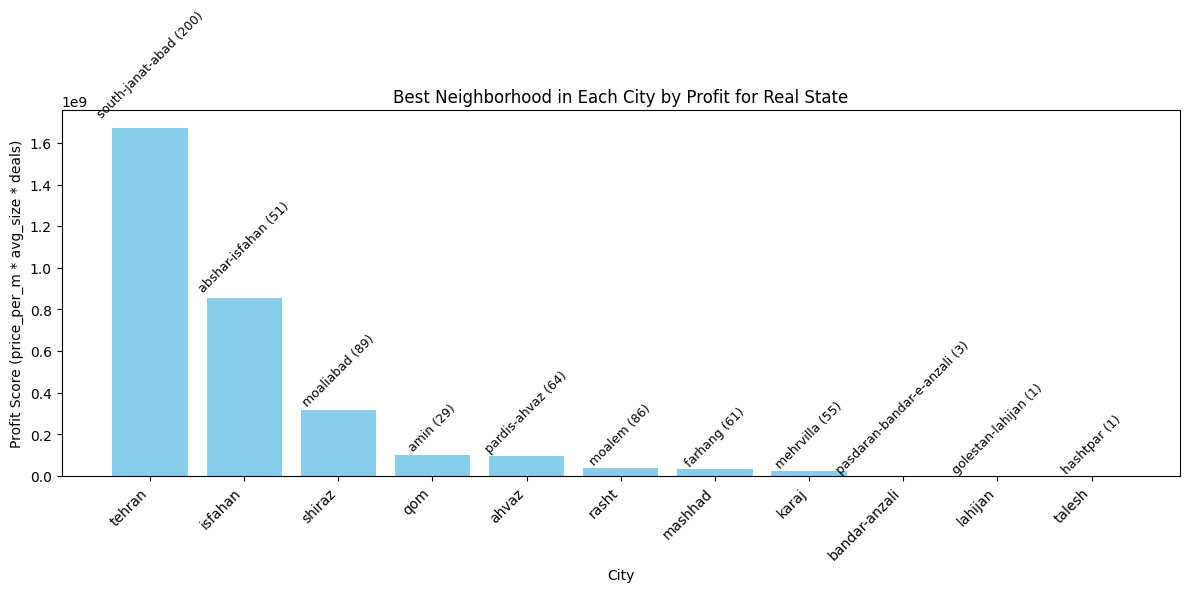

In [19]:
df = data2[['city_slug', 'neighborhood_slug', 'price_per_meter','building_size','price_value']].copy()

# Group by city_slug and neighborhood_slug
grouped = df.groupby(['city_slug','neighborhood_slug']).agg(
    avg_price_value=('price_value', 'mean'),
    avg_price_per_m=('price_per_meter', 'mean'),
    avg_size=('building_size', 'mean'),
    deal_count=('price_value', 'count')
).reset_index()

# formula is profit_score = price_per_m * size_of_house * number of contract
grouped['profit_score'] = grouped['avg_price_per_m'] * grouped['avg_size'] * grouped['deal_count']

best_neighborhoods = grouped.loc[grouped.groupby('city_slug')['profit_score'].idxmax()]
best_neighborhoods = best_neighborhoods.sort_values('profit_score', ascending=False)

#print(best_neighborhoods)

plt.figure(figsize=(12,6))
bars = plt.bar(best_neighborhoods['city_slug'], best_neighborhoods['profit_score'], color='skyblue')

# Step 3: Add neighborhood name and number of deals on top of each bar
for bar, neigh, deals in zip(bars, best_neighborhoods['neighborhood_slug'], best_neighborhoods['deal_count']):
    height = bar.get_height()
    # Write neighborhood name
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + height*0.02,
        f"{neigh} ({deals})",
        ha='center', va='bottom', fontsize=9, rotation=45,
        color='black'
    )

plt.xticks(rotation=45, ha='right')
plt.title('Best Neighborhood in Each City by Profit for Real State')
plt.xlabel('City')
plt.ylabel('Profit Score (price_per_m * avg_size * deals)')
plt.tight_layout()
plt.show()


In [10]:
data.columns

Index(['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 'rent_mode',
       'rent_value', 'rent_to_single', 'rent_type', 'price_mode',
       'price_value', 'credit_mode', 'credit_value', 'rent_credit_transform',
       'transformable_price', 'transformable_credit', 'transformed_credit',
       'transformable_rent', 'transformed_rent', 'land_size', 'building_size',
       'deed_type', 'has_business_deed', 'floor', 'rooms_count',
       'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt',
       'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type',
       'regular_person_capacity', 'extra_person